In [3]:
# TensorFlow, keras, np
import numpy as np
import time
import sys

from io import UnsupportedOperation
import pickle as pkl

import matplotlib.pyplot as plt


# Add shared location for auxillary functions
sys.path.insert(1, './../AuxillaryFunctions')

# import personal Functions
from GenerateClassDataFuncs import GenerateDataAndClasses_ClemCafe_WinCnt
from GenerateClassDataFuncs import GenerateDataAndClasses_ClemCafe_Bite
from GenerateClassDataFuncs import GenerateDataAndClasses_OREBA_WinCnt

In [4]:
DEBUG_PRINTS = 1 # Set to 1 for additional Prints throughout the file,
				# clear to 0 for only final output
VERBOSE_PRINT = 1 # set to 1 for Lengthy Output, 0 for single line
TIMING_PRINT = 0 # Set to 1 if prints for times should be made, 0 if not desired

#define constants for the data
FOLDS_TOTAL = 0
FOLD_INDEX = 0 # wrap data into valid fold number in case fold 
				# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL) 
RR_FLAG = 1 # 1 if using striped fold division, 0 if using block fold division
CUT_sec = 15 # the total length of the window in [sec]
STRIDE_sec = 1 # The time to move between each window when making examples in [sec]
DATABASE_FLAG = 4

RESAMPLE_FLAG_FREQ = 1


if DATABASE_FLAG == 1:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"
elif DATABASE_FLAG == 2:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA_TwoHands.pkl"
elif DATABASE_FLAG == 3:
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
elif DATABASE_FLAG == 4:
	DATABASE_FILEPATH = "./../Pickle_Databases/CleanClemCafe.pkl"
elif DATABASE_FLAG == 5:
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemDomPkl.pkl"
elif DATABASE_FLAG == 6:
	DATABASE_FILEPATH = "./../Pickle_Databases/OHO_Dom.pkl"
else:
	print("!!! WARNING: INVALID DATABASE SELECTION FLAG VALUE OF {} !!!".format(DATABASE_FLAG))
	print("Expects value of:")
	print("\t1 = OneHand OREBA")
	print("\t2 = TwoHand OREBA")
	print("\t3 = ClemCafe Data")
	print("Defaulting to use of ClemCafeData...")
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
#end of Database switch statement



SMOOTHING_FACTOR = 0 # the number of data points to either side to smooth the raw data
WINDOWS_PER_BATCH = 128 # Batch-size for the model


if DEBUG_PRINTS == 1:
	print('CUT_sec Input is ',CUT_sec)
	print('STRIDE_sec input is ',STRIDE_sec)
	print('Training Data coming from file ',DATABASE_FILEPATH)
	print('RR_Flag Input is ',RR_FLAG)
	print('Fold_Index Input is ',FOLD_INDEX)
	print('Folds_Total Input is ',FOLDS_TOTAL)

	print("python setup complete")
# end of DEBUG_PRINTS

if TIMING_PRINT == 1:
	print("Parsing Eval Data...")
	start=time.time()
# end of TIMING_PRINT



CUT_sec Input is  15
STRIDE_sec input is  1
Training Data coming from file  ./../Pickle_Databases/CleanClemCafe.pkl
RR_Flag Input is  1
Fold_Index Input is  0
Folds_Total Input is  0
python setup complete


In [5]:
CUT_sec = 15

MAX_BITES = 5
Histogram_OH = np.zeros([MAX_BITES+1])
Histogram_DM = np.zeros([MAX_BITES+1])
Histogram_CC = np.zeros([MAX_BITES+1])


DATABASE_FILEPATH = "./../Pickle_Databases/OHO_Dom.pkl"
DataFreq = RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
training_data,classes_OREBA = GenerateDataAndClasses_OREBA_WinCnt(
			CUT_sec*DataFreq, STRIDE_sec*DataFreq,
			DATABASE_FILEPATH,
			FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ
			)

for i in range(len(classes_OREBA)):
	Histogram_OH[min(MAX_BITES,classes_OREBA[i])]+=1
#end of for loop
print("Done with OREBA One Hand Histogram")

	
# DATABASE_FILEPATH = "./../Pickle_Databases/OREBA_TwoHands.pkl"
# DataFreq = RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
# training_data,classes = GenerateDataAndClasses_OREBA_WinCnt(
# 			CUT_sec*DataFreq, STRIDE_sec*DataFreq,
# 			DATABASE_FILEPATH,
# 			FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
# 			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ
# 			)
# for i in range(len(classes)):
# 	Histogram_DM[classes[i]]+=1
# #end of for loop
# print("Done with OREBA Two Hand Histogram")


DATABASE_FILEPATH = "./../Pickle_Databases/ClemDomPkl.pkl"
DataFreq = RESAMPLE_FLAG_FREQ # [Hz]
training_data,classes_CC = GenerateDataAndClasses_ClemCafe_WinCnt(
			CUT_sec*DataFreq, STRIDE_sec*DataFreq,
			DATABASE_FILEPATH,
			FOLD_INDEX, FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG = RESAMPLE_FLAG_FREQ
			#, RESAMPLE_FLAG=0, SMOOTHING=0 # optional flags not currently used for Paper Experiment
			)
for i in range(len(classes_CC)):
	Histogram_CC[min(MAX_BITES,classes_CC[i])]+=1
#end of for loop
print("Done with ClemCafe Histogram")

print("FINISHED with making data...")

	

Done with OREBA One Hand Histogram
Done with ClemCafe Histogram
FINISHED with making data...


In [ ]:
print(classes_OREBA[i-10])

In [ ]:
DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
DataFreq = RESAMPLE_FLAG_FREQ # [Hz]
training_data,classes_CC = GenerateDataAndClasses_ClemCafe_Bite(
			CUT_sec*DataFreq, STRIDE_sec*DataFreq,
			DATABASE_FILEPATH,
			FOLD_INDEX, FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG = RESAMPLE_FLAG_FREQ
			#, RESAMPLE_FLAG=0, SMOOTHING=0 # optional flags not currently used for Paper Experiment
			)


print("Finished Making CC Bite Data")

In [10]:
print(sum(classes_CC))
print(len(classes_CC))
print(classes_CC[4:40])

308926
397771
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 1 2 2 2 2]


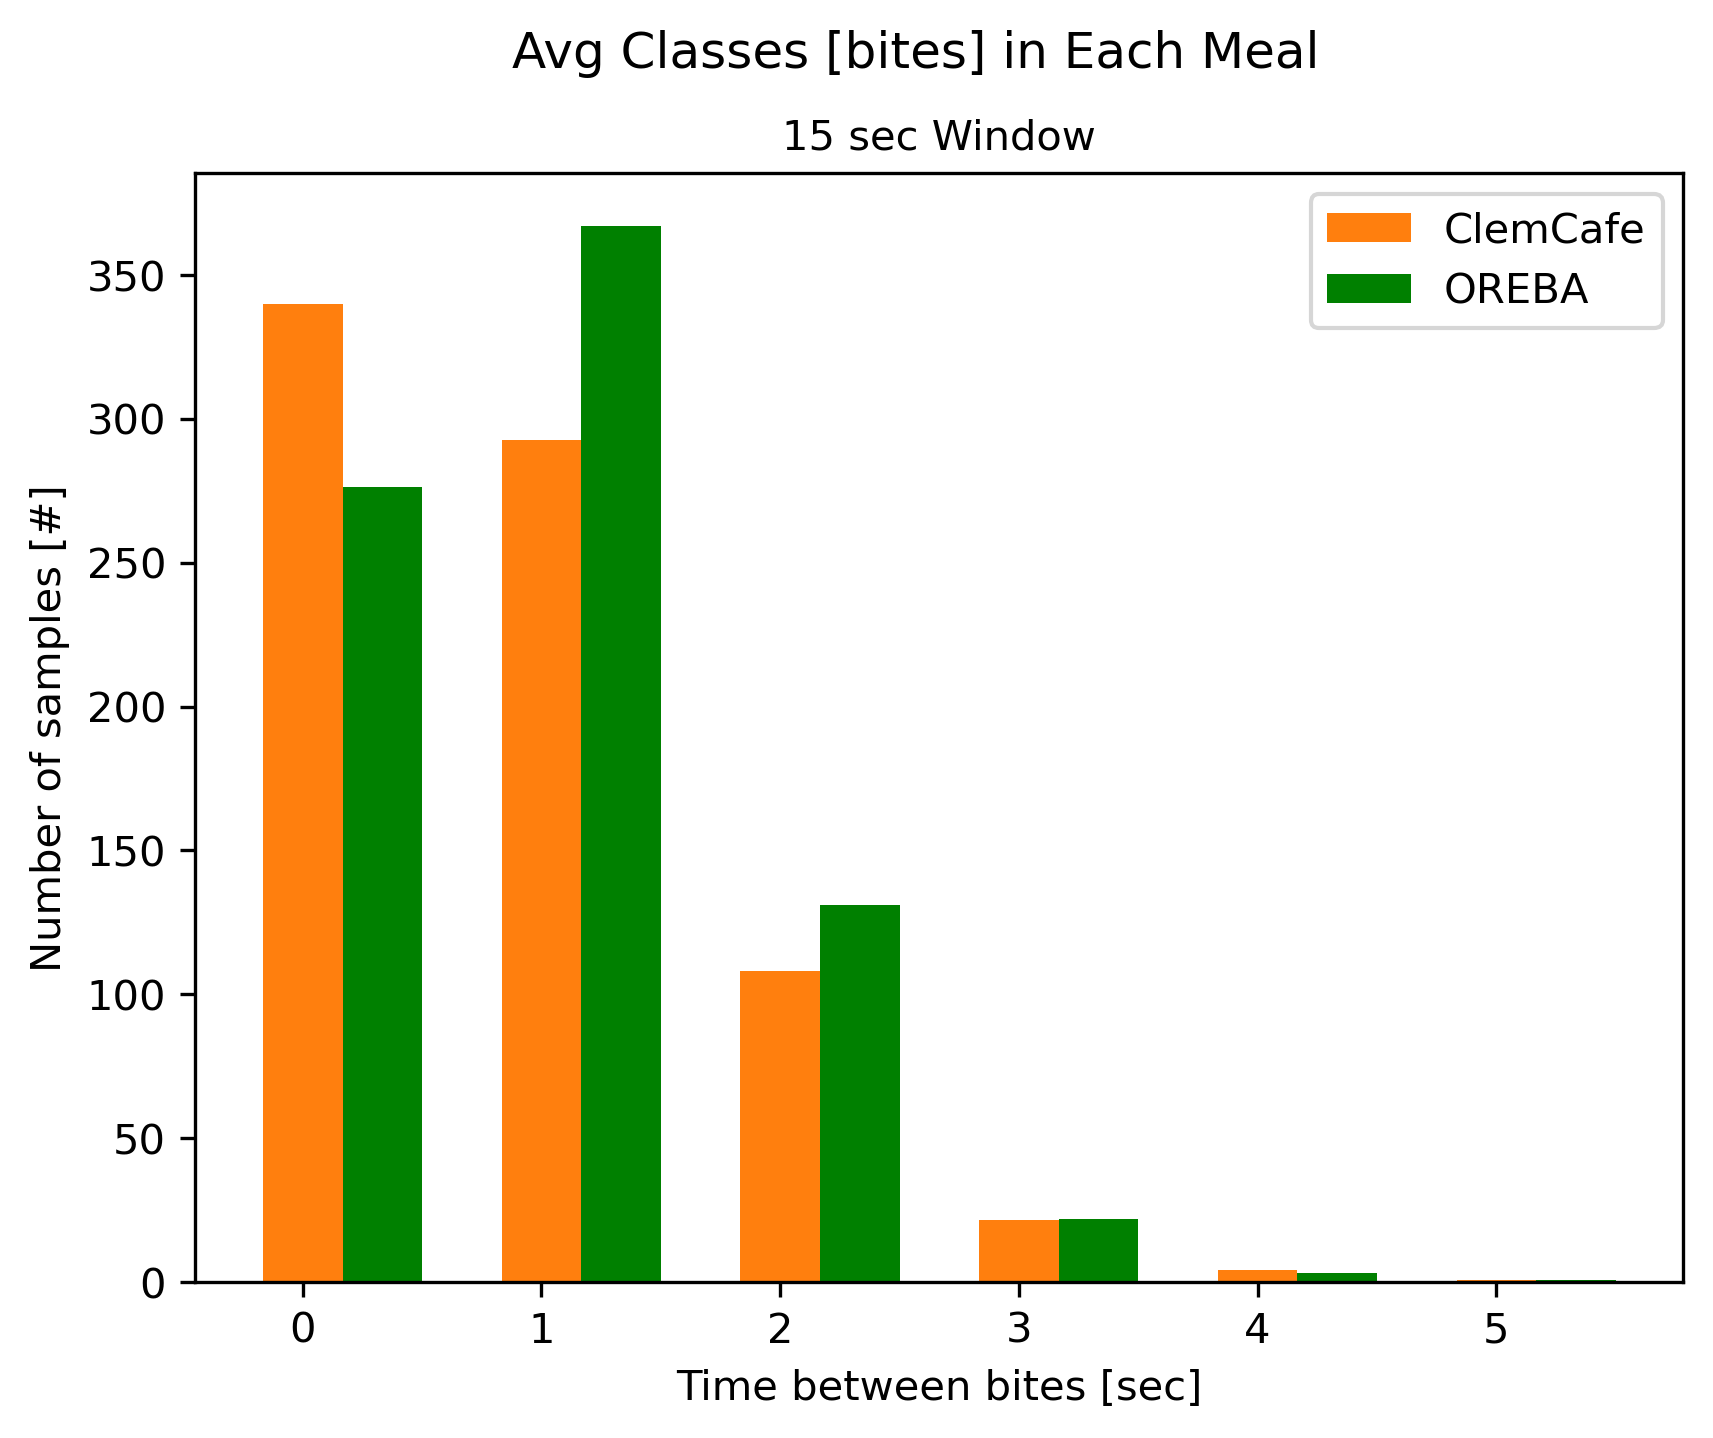

In [6]:
# PLOT_DM  = 0
PLOT_OH  = 1
PLOT_CC  = 1

NORMALIZE_BITES_PER_MEAL = 1

OREBA_num_meals = 100
CC_num_meals = 518

	

# totalPlots = PLOT_CC + PLOT_OH + PLOT_DM
totalPlots = PLOT_CC + PLOT_OH + 1 # add one to give a space between the bars
width = 1/totalPlots
PlotsDone = 0

MaxBins=MAX_BITES
indices = np.arange(0,MaxBins+1)



if NORMALIZE_BITES_PER_MEAL == 1:
	ydata_OH = Histogram_OH[:MaxBins+1]/OREBA_num_meals
# 	ydata_DM = Histogram_DM[:MaxBins+1]/OREBA_num_meals
	ydata_CC = Histogram_CC[:MaxBins+1]/CC_num_meals
else:
	ydata_OH = Histogram_OH[:MaxBins+1]
# 	ydata_DM = Histogram_DM[:MaxBins+1]
	ydata_CC = Histogram_CC[:MaxBins+1]


plt.figure("w",dpi=300)

legendEntries=[]
if PLOT_CC == 1:
	plt.bar(indices, ydata_CC, width=width, 
			color='tab:orange', label='ClemCafe')
	legendEntries.append("ClemCafe")
	PlotsDone+=1
if PLOT_OH == 1:
	plt.bar([i+PlotsDone*width for i in indices], ydata_OH, 
			width=width, color='g', alpha=1.0, label='OREBA')
	legendEntries.append("OREBA")
	PlotsDone+=1

# if PLOT_DM == 1:
# 	plt.bar([i+PlotsDone*width for i in indices], ydata_DM, 
# 			width=width, color='b', alpha=0.9, label='TwoHand OREBA')
# 	legendEntries.append("TwoHand")
# 	PlotsDone+=1

plt.legend(legendEntries)


plt.suptitle("Avg Classes [bites] in Each Meal")

plt.title("{} sec Window".format(CUT_sec),fontsize=10)
plt.xlabel('Time between bites [sec]')
plt.ylabel('Number of samples [#]')

plt.xticks(indices)
plt.savefig("Histogram_WinSz{}_Classes_PerMeal.png".format(CUT_sec))

In [ ]:
### PLot a meal of classes ###

MealDuration=600 #sec
currMeal = classes_CC[:MealDuration]

ydata = currMeal
xdata = np.array(range(0,MealDuration,STRIDE_sec))

plt.figure('w',dpi=300)
plt.step(xdata,ydata)


plt.suptitle("Example Bites in Window Ground Truth")
plt.title("{} sec Window".format(CUT_sec),fontsize=10)

plt.xlabel('Time [sec]')
plt.ylabel('Number of Bites in Window [#]')

plt.savefig("ExampleMeal_WinSz{}.png".format(CUT_sec))

In [ ]:
options_CUT_sec = [5, 10,15,20,25,30]

All_CC_HistoData = []
All_OREBA_HistoData = []
All_Avg_HistoData = []


for curr_CUT_idx in range(len(options_CUT_sec)):
	CUT_sec = options_CUT_sec[curr_CUT_idx] #overwrite previous single value to keep the rest of the code without refactoring

	MAX_BITES = 7
	Histogram_OH = np.zeros([MAX_BITES+1])
	Histogram_DM = np.zeros([MAX_BITES+1])
	Histogram_CC = np.zeros([MAX_BITES+1])


	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"
	DataFreq = RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
	training_data,classes_OREBA = GenerateDataAndClasses_OREBA_WinCnt(
				CUT_sec*DataFreq, STRIDE_sec*DataFreq,
				DATABASE_FILEPATH,
				FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
				RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ
				)

	for i in range(len(classes_OREBA)):
		Histogram_OH[min(MAX_BITES,classes_OREBA[i])]+=1
	#end of for loop
	print("Done with OREBA One Hand Histogram")


	# DATABASE_FILEPATH = "./../Pickle_Databases/OREBA_TwoHands.pkl"
	# DataFreq = RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
	# training_data,classes = GenerateDataAndClasses_OREBA_WinCnt(
	# 			CUT_sec*DataFreq, STRIDE_sec*DataFreq,
	# 			DATABASE_FILEPATH,
	# 			FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
	# 			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ
	# 			)
	# for i in range(len(classes)):
	# 	Histogram_DM[classes[i]]+=1
	# #end of for loop
	# print("Done with OREBA Two Hand Histogram")


	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
	DataFreq = RESAMPLE_FLAG_FREQ # [Hz]
	training_data,classes_CC = GenerateDataAndClasses_ClemCafe_WinCnt(
				CUT_sec*DataFreq, STRIDE_sec*DataFreq,
				DATABASE_FILEPATH,
				FOLD_INDEX, FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
				RESAMPLE_FLAG = RESAMPLE_FLAG_FREQ
				#, RESAMPLE_FLAG=0, SMOOTHING=0 # optional flags not currently used for Paper Experiment
				)
	for i in range(len(classes_CC)):
		Histogram_CC[min(MAX_BITES,classes_CC[i])]+=1
	#end of for loop
	print("Done with ClemCafe Histogram")

	print("FINISHED with making data for stride {}...".format(CUT_sec))

	All_CC_HistoData.append(Histogram_CC)
	All_OREBA_HistoData.append(Histogram_OH)
	All_Avg_HistoData.append(Histogram_CC+Histogram_OH)

	
# end of for curr_Cut_sec_idx

print("DONE WITH ALL STRIDES!!!")
	

In [ ]:



DataSelect = 0
# 0 = Average of all Meals on all datasets
# 1 = OREBA Dataset
# 2 = ClemCafe Dataset

NORMALIZE_BITES_PER_MEAL = 1


OREBA_num_meals = 100
CC_num_meals = 518

if DataSelect == 1:
	HistoData = All_Avg_HistoData
	num_meals = OREBA_num_meals
elif DataSelect == 2:
	HistoData = All_Avg_HistoData
	num_meals = CC_num_meals
else: #if DataSelect = 0
	HistoData = [All_Avg_HistoData[0],All_Avg_HistoData[1],All_Avg_HistoData[2],All_Avg_HistoData[3],All_Avg_HistoData[4]]
	num_meals = OREBA_num_meals + CC_num_meals
#end of DataSelect switch

# totalPlots = PLOT_CC + PLOT_OH + PLOT_DM
totalPlots = len(HistoData) + 1 # add one to give a space between the bars
width = 1/totalPlots
PlotsDone = 0

MaxBins=MAX_BITES
MaxBins=4
indices = np.arange(0,MaxBins+1)



if NORMALIZE_BITES_PER_MEAL == 1:
	ydata = []
	for i in range(len(HistoData)):
		ydata.append(HistoData[i][:MaxBins+1]/num_meals)
else:
	ydata = []
	for i in range(len(HistoData)):
		ydata.append(HistoData[i][:MaxBins+1])
#end of if Normalize_Bites_PER_MEAL

		
		
plt.figure("w",dpi=300)

legendEntries=[]
color_opts = ['b','tab:orange','g','k','tab:purple','tab:blue','k','tab:grey']

for i in range(len(HistoData)):
	plt.bar([i+PlotsDone*width-len(HistoData)/2*width for i in indices], (ydata[i]/sum(ydata[i])*100), width=width, 
			color=color_opts[i], label=str(options_CUT_sec[i]))
	legendEntries.append(str(options_CUT_sec[i])+" sec Window")
	PlotsDone+=1
#end of plot loop


plt.legend(legendEntries)


# plt.suptitle("Class Labels for Various Window Sizes")

# plt.title("Avg # Classes in a Meal",fontsize=10)
plt.xlabel('Class Label [# Bites]')
plt.ylabel('Percent of Samples [%]')

plt.xticks(indices)
plt.savefig("Histogram_Percent_MultiStride_Classes_PerMeal.pdf", bbox='tight')

In [ ]:



DataSelect = 0
# 0 = Average of all Meals on all datasets
# 1 = OREBA Dataset
# 2 = ClemCafe Dataset

NORMALIZE_BITES_PER_MEAL = 1


OREBA_num_meals = 100
CC_num_meals = 518

if DataSelect == 1:
	HistoData = All_Avg_HistoData
	num_meals = OREBA_num_meals
elif DataSelect == 2:
	HistoData = All_Avg_HistoData
	num_meals = CC_num_meals
else: #if DataSelect = 0
	HistoData = All_Avg_HistoData
	num_meals = OREBA_num_meals + CC_num_meals
#end of DataSelect switch

# totalPlots = PLOT_CC + PLOT_OH + PLOT_DM
totalPlots = len(HistoData) + 1 # add one to give a space between the bars
width = 1/totalPlots
PlotsDone = 0

MaxBins=MAX_BITES
indices = np.arange(0,MaxBins+1)



if NORMALIZE_BITES_PER_MEAL == 1:
	ydata = []
	for i in range(len(HistoData)):
		ydata.append(HistoData[i][:MaxBins+1]/num_meals)
else:
	ydata = []
	for i in range(len(HistoData)):
		ydata.append(HistoData[i][:MaxBins+1])
#end of if Normalize_Bites_PER_MEAL

		
		
plt.figure("w",dpi=300)

legendEntries=[]
color_opts = ['tab:purple','tab:green','tab:orange','tab:blue','k','tab:grey']
marker = 'd'

for i in range(len(HistoData)):
	plt.plot(indices, ydata[i], 
			color=color_opts[i], marker = marker, label=str(options_CUT_sec[i]))
	legendEntries.append(str(options_CUT_sec[i]))
	PlotsDone+=1
#end of plot loop


plt.legend(legendEntries)


plt.suptitle("Class Labels for Various Window Sizes")

plt.title("Avg # Classes in a Meal",fontsize=10)
plt.xlabel('Class Label [# Bites]')
plt.ylabel('Number of samples [#]')

plt.xticks(indices)
plt.savefig("Plot_MultiStride_Classes_PerMeal.png")

In [14]:
with open("../Pickle_Databases/OHO_Dom_v2.pkl",'rb') as fh:
	dataset = pkl.load(fh)
# end of open



In [21]:

testID=26
print(len(dataset['bites_handedness_gt'][testID]))
print(len(dataset['bites_gt'][testID]))
print(dataset['handedness'][testID])
print(dataset['bites_handedness_gt'][testID])


74
74
right
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


100
